<a href="https://colab.research.google.com/github/ICSM/pgmuvi/blob/main/docs/source/notebooks/PGMUVI_comparison_with_other_codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing GP packages on synthetic light curves

This tutorial makes it easy to compare **eight** Gaussian process libraries
commonly used in science and machine learning:
`pgmuvi`, `tinygp`, `celerite2`, `george`, `GPy`, `gpflow`,
`scikit-learn.gaussian_process`, and `gpjax`.
Because of dependency clashes, we're only going to run the comparison with 5 of
them, skipping over `GPy`, `gpflow`, and `gpjax`, but you can always run this
notebook yourself to compare them too if you're curious.

We use **the same covariance kernel** (or its nearest equivalent) in every tool
and compare:

- the amount of user code required,
- wall-clock fitting times,
- inferred PSDs and fit quality, and
- which tools natively support multiwavelength (2D) data.

## Mathematical framework

All tools model data with a Gaussian process (GP):

$$y(\mathbf{x}) \sim \mathcal{GP}(m(\mathbf{x}),\; k(\mathbf{x},\mathbf{x}')),$$

with a constant mean $m$ and a covariance kernel $k$.

We use the **Spectral Mixture Kernel** (SMK; Wilson & Adams 2013):

$$k_\mathrm{SM}(\tau) = \sum_{q=1}^{Q} w_q\;\exp\!\bigl(-2\pi^2 v_q^2 \tau^2\bigr)\;\cos(2\pi \mu_q \tau),$$

where $\mu_q$ are mixture frequencies, $v_q$ are bandwidths, and $w_q$ are weights.

For `scikit-learn` we use $\mathrm{RBF} \times \sin^2$ (quasi-periodic kernel).
For `celerite2` we use the **SHOTerm**:

$$k_\mathrm{SHO}(\tau) \approx \sigma^2\exp\!\Bigl(-\tfrac{\omega_0}{2Q}|\tau|\Bigr)\cos(\omega_0 \tau), \quad Q \gg \tfrac12,$$

which has a Lorentzian (not Gaussian) power spectrum.
All other tools implement the SMK exactly.

## Installation

The cell below installs any missing packages. It is safe to re-run.

In [19]:
try:
    import pgmuvi
except (ModuleNotFoundError, ImportError):
    %pip install git+https://github.com/ICSM/pgmuvi@main

try:
    import george
except (ModuleNotFoundError, ImportError):
    %pip install george

try:
    import celerite2
except (ModuleNotFoundError, ImportError):
    %pip install celerite2

try:
    import tinygp
    import equinox
    import optax
except (ModuleNotFoundError, ImportError):
    %pip install tinygp equinox optax jax

# try:
#     import gpjax
# except (ModuleNotFoundError, ImportError):
#     %pip install jax[cpu]
#     %pip install gpjax


# try:
#     import GPy
# except (ModuleNotFoundError, ImportError):
#     # _pip('GPy')
#     %pip install GPy

# try:
#     import gpflow
# except (ModuleNotFoundError, ImportError):
#     # _pip('gpflow')
#     %pip install gpflow

# try:
#     from sklearn.gaussian_process import GaussianProcessRegressor
# except (ModuleNotFoundError, ImportError):
#     # _pip('scikit-learn')
#     %pip install scikit-learn



print('Installation check complete.')

Installation check complete.


## Imports

In [20]:
import textwrap
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from pgmuvi.lightcurve import Lightcurve as LC
from pgmuvi.synthetic import make_simple_sinusoid_1d, make_chromatic_sinusoid_2d, make_multi_sinusoid_chromatic_2d

# Storage dicts
preds_1d   = {}   # name -> (x_grid, mean, std)
psds_1d    = {}   # name -> (freq, power)
timings    = {}
code_lines = {}

# --- optional celerite2 ---
try:
    import celerite2
    from celerite2 import terms as c2terms
    from scipy.optimize import minimize
    HAVE_CELERITE = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_CELERITE = False
    print(f'celerite2 not available: {e}')

# --- optional tinygp + JAX + optax ---
try:
    import jax
    import jax.numpy as jnp
    import equinox as eqx
    import optax
    from tinygp import GaussianProcess as TinyGP
    from tinygp.kernels.base import Kernel as TinyKernel
    HAVE_TINYGP = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_TINYGP = False
    print(f'tinygp not available: {e}')

# --- optional george ---
try:
    import george
    from george import kernels as gk
    from scipy.optimize import minimize as scipy_minimize
    HAVE_GEORGE = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_GEORGE = False
    print(f'george not available: {e}')

# --- optional GPy ---
try:
    import GPy
    HAVE_GPY = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_GPY = False
    print(f'GPy not available: {e}')

# --- optional gpflow ---
try:
    import gpflow
    HAVE_GPFLOW = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_GPFLOW = False
    print(f'gpflow not available: {e}')

# --- optional scikit-learn ---
try:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import (
        RBF, ExpSineSquared, ConstantKernel)
    HAVE_SKLEARN = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_SKLEARN = False
    print(f'scikit-learn not available: {e}')

# --- optional gpjax ---
try:
    import gpjax
    HAVE_GPJAX = True
except (ModuleNotFoundError, ImportError) as e:
    HAVE_GPJAX = False
    print(f'gpjax not available: {e}')

print('\nPackage availability:')
for _name, _flag in [
    ('celerite2', HAVE_CELERITE), ('tinygp', HAVE_TINYGP),
    ('george', HAVE_GEORGE), ('GPy', HAVE_GPY),
    ('gpflow', HAVE_GPFLOW), ('sklearn', HAVE_SKLEARN),
    ('gpjax', HAVE_GPJAX)
]:
    print(f'  {_name:<12s}: {"ok" if _flag else "SKIPPED"}')

def count_lines(snippet):
    return sum(1 for ln in textwrap.dedent(snippet).splitlines() if ln.strip())

GPy not available: No module named 'GPy'
gpflow not available: No module named 'gpflow'
gpjax not available: cannot import name 'xla_pmap_p' from 'jax.extend.core.primitives' (/usr/local/lib/python3.12/dist-packages/jax/extend/core/primitives.py)

Package availability:
  celerite2   : ok
  tinygp      : ok
  george      : ok
  GPy         : SKIPPED
  gpflow      : SKIPPED
  sklearn     : ok
  gpjax       : SKIPPED


## Synthetic datasets

We generate reproducible synthetic light curves with a known period of
$T = 40\,\mathrm{d}$.

In [21]:
SEED = 0
WAVELENGTHS = [0.8, 1.2, 2.2]

""" Generate a set of light curves with two period components and a phase lag"""
n_per_band = (25, 100) # number of data points per light curve limited to this range

TRUE_PERIODS = (150.0, 66.0)
TRUE_PERIOD = TRUE_PERIODS[0]
TRUE_FREQ = 1/TRUE_PERIOD
Q_MIXTURES  = 2      # mixture components used by all tools


MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": TRUE_PERIODS[0], "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": TRUE_PERIODS[1], "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=WAVELENGTHS,
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc_2d = make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG).double()

# Extract the better-sampled wavelength and make a new 1D lightcurve
# First identify which wavelength is better sampled:

wave_counts = np.unique(lc_2d.xdata[:,1], return_counts=True)
print(wave_counts)
best_wave = wave_counts[0][np.argmax(wave_counts[1])]
print(best_wave)

times_1d = lc_2d.xdata[lc_2d.xdata[:,1] == best_wave][:, 0]
flux_1d = lc_2d.ydata[lc_2d.xdata[:,1] == best_wave]
errs_1d = lc_2d.yerr[lc_2d.xdata[:,1] == best_wave]

lc_1d = LC(times_1d, flux_1d, yerr=errs_1d).double()



(array([0.80000001, 1.20000005, 2.20000005]), array([89, 73, 63]))
0.800000011920929


In [22]:
# TRUE_PERIOD = 40.0   # days
# TRUE_FREQ   = 1.0 / TRUE_PERIOD


# lc_1d = make_simple_sinusoid_1d(
#     n_obs=120, period=TRUE_PERIOD, amplitude=1.0,
#     noise_level=0.2, noise_type='gaussian', irregular=True, seed=1,
# ).double()

# WAVELENGTHS = [0.5, 0.8, 1.2]
# lc_2d = make_chromatic_sinusoid_2d(
#     n_per_band=[80, 70, 60],
#     period=TRUE_PERIOD,
#     wavelengths=WAVELENGTHS,
#     amplitude_law='linear',
#     amplitude=1.0,
#     amplitude_slope=0.6,
#     noise_level=0.15,
#     t_span=180.0,
#     irregular=True,
#     seed=2,
# ).double()



# Convenience numpy arrays for 1D data
x1    = lc_1d.xdata.detach().cpu().numpy()
y1    = lc_1d.ydata.detach().cpu().numpy()
ye1   = lc_1d.yerr.detach().cpu().numpy()
mean1 = float(np.mean(y1))

# Prediction grid
x_grid = np.linspace(x1.min(), x1.max(), 300)

print('1D dataset :', len(x1), 'points')
print('2D dataset :', len(lc_2d.xdata), 'points, ndim =', lc_2d.ndim)

1D dataset : 89 points
2D dataset : 225 points, ndim = 2


## 1D (single-wavelength) comparison

We fit the same 1D light curve with all available tools.
Each tool uses the Spectral Mixture Kernel with $Q = 2$ components,
initialised with the true period and its first harmonic.
`celerite2` uses the SHOTerm approximation (see [Mathematical framework](#Mathematical-framework)).

### `pgmuvi` — 1D spectral mixture GP

In [23]:
t0 = time.perf_counter()
res_pgmuvi_1d = lc_1d.fit(
    model='1D',
    num_mixtures=Q_MIXTURES,
    training_iter=1000,
    miniter=50,
    lr=0.05,
)
timings['pgmuvi'] = time.perf_counter() - t0
code_lines['pgmuvi'] = count_lines("""
    res = lc_1d.fit(model='1D', num_mixtures=2, training_iter=1000)
""")

print('pgmuvi 1D  | loss:', round(float(res_pgmuvi_1d['loss'][-1]), 3),
      ' | time:', round(timings['pgmuvi'], 2), 's')
mm = lc_1d.model.covar_module.mixture_means.detach().cpu().squeeze().numpy()
print('  fitted frequencies:', mm, '  -> periods:', 1.0 / mm)

# Predictions
lc_1d.model.eval()
with torch.no_grad():
    x_t  = torch.tensor(x_grid[:, None], dtype=torch.float64)
    pred = lc_1d.model.likelihood(lc_1d.model(x_t))
    mu_p  = pred.mean.numpy()
    std_p = pred.variance.sqrt().numpy()
preds_1d['pgmuvi'] = (x_grid, mu_p, std_p)

# Analytical SMK PSD
freqs_arr = np.linspace(0, 0.2, 2000)
mms = lc_1d.model.covar_module.mixture_means.detach().cpu().squeeze().numpy()
mss = lc_1d.model.covar_module.mixture_scales.detach().cpu().squeeze().numpy()
mws = lc_1d.model.covar_module.mixture_weights.detach().cpu().squeeze().numpy()
psd_p = np.zeros_like(freqs_arr)
for w, mu, v in zip(mws, mms, mss):
    psd_p += w * (np.exp(-0.5 * ((freqs_arr - mu) / v)**2)
                 + np.exp(-0.5 * ((freqs_arr + mu) / v)**2))
psds_1d['pgmuvi'] = (freqs_arr, psd_p / psd_p.max())

mean_module.constant: 0.028102993965148926
covar_module.mixture_weights: tensor([0.4779, 0.4779])
covar_module.mixture_means: tensor([[[0.0067]],

        [[0.0154]]])
covar_module.mixture_scales: tensor([[[0.0053]],

        [[0.0037]]])


100%|██████████| 1000/1000 [00:11<00:00, 89.56it/s]

pgmuvi 1D  | loss: -1.562  | time: 11.19 s
  fitted frequencies: [0.00665436 0.0151593 ]   -> periods: [150.27731   65.966125]



/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


### `tinygp` — custom 1D spectral mixture kernel

Because `tinygp` ships no SMK, we subclass `tinygp.kernels.base.Kernel`
to implement the identical formula used by `gpytorch.kernels.SpectralMixtureKernel`.

In [24]:
class SMK1D(TinyKernel if HAVE_TINYGP else object):
    r'''1-D Spectral Mixture Kernel.

    k(tau) = sum_q  w_q * cos(2*pi*mu_q*tau) * exp(-2*pi^2*v_q^2*tau^2)

    Parameters are stored in log-space for unconstrained optimisation.
    '''
    log_weights : 'jnp.ndarray'  # (Q,)
    log_freqs   : 'jnp.ndarray'  # (Q,) mu_q [cycles/unit]
    log_scales  : 'jnp.ndarray'  # (Q,) v_q  [cycles/unit]

    def evaluate(self, X1, X2):
        w   = jnp.exp(self.log_weights)
        mu  = jnp.exp(self.log_freqs)
        v   = jnp.exp(self.log_scales)
        tau = X1 - X2
        return jnp.sum(
            w * jnp.cos(2 * jnp.pi * mu * tau)
              * jnp.exp(-2 * jnp.pi**2 * v**2 * tau**2)
        )


if HAVE_TINYGP:
    x_j  = jnp.asarray(x1)
    y_j  = jnp.asarray(y1)
    ye_j = jnp.asarray(ye1)

    kernel_tiny_1d = SMK1D(
        log_weights=jnp.log(jnp.ones(Q_MIXTURES) * 0.5),
        log_freqs  =jnp.log(jnp.array([TRUE_FREQ, 2 * TRUE_FREQ])),
        log_scales =jnp.log(jnp.ones(Q_MIXTURES) * 0.002),
    )

    @jax.jit
    @jax.value_and_grad
    def _neg_ll_tiny1d(params):
        gp = TinyGP(params, x_j, diag=ye_j**2, mean=mean1)
        return -gp.log_probability(y_j)

    opt_t  = optax.adam(0.05)
    state_t = opt_t.init(eqx.filter(kernel_tiny_1d, eqx.is_inexact_array))

    t0 = time.perf_counter()
    for _ in range(1000):
        loss_t, grads_t = _neg_ll_tiny1d(kernel_tiny_1d)
        updates_t, state_t = opt_t.update(
            grads_t, state_t,
            eqx.filter(kernel_tiny_1d, eqx.is_inexact_array))
        kernel_tiny_1d = eqx.apply_updates(kernel_tiny_1d, updates_t)
    timings['tinygp'] = time.perf_counter() - t0
    code_lines['tinygp'] = count_lines("""
        class SMK1D(TinyKernel):
            log_weights: jnp.ndarray
            log_freqs:   jnp.ndarray
            log_scales:  jnp.ndarray
            def evaluate(self, X1, X2):
                w, mu, v = map(jnp.exp, (self.log_weights, self.log_freqs, self.log_scales))
                tau = X1 - X2
                return jnp.sum(w * jnp.cos(2*jnp.pi*mu*tau) * jnp.exp(-2*jnp.pi**2*v**2*tau**2))
        kernel = SMK1D(log_weights=..., log_freqs=..., log_scales=...)
        @jax.jit
        @jax.value_and_grad
        def neg_ll(k): return -TinyGP(k, x, diag=yerr**2).log_probability(y)
        for _ in range(150):
            loss, grads = neg_ll(kernel)
            updates, state = opt.update(grads, state, eqx.filter(kernel, eqx.is_inexact_array))
            kernel = eqx.apply_updates(kernel, updates)
    """)

    freqs_fit_t = np.exp(np.asarray(kernel_tiny_1d.log_freqs))
    print('tinygp 1D  | loss:', round(float(loss_t), 3),
          ' | time:', round(timings['tinygp'], 2), 's')
    print('  fitted periods:', 1.0 / freqs_fit_t)

    # Predictions: condition(y, X_test).gp.loc gives predictive mean
    xg_j = jnp.asarray(x_grid)
    mu_t_arr = np.asarray(
        TinyGP(kernel_tiny_1d, x_j, diag=ye_j**2, mean=mean1)
        .condition(y_j, xg_j).gp.loc)
    preds_1d['tinygp'] = (x_grid, mu_t_arr, None)

    # Analytical SMK PSD
    freqs_arr = np.linspace(0, 0.2, 2000)
    mmu_t = np.exp(np.asarray(kernel_tiny_1d.log_freqs))
    mvv_t = np.exp(np.asarray(kernel_tiny_1d.log_scales))
    mww_t = np.exp(np.asarray(kernel_tiny_1d.log_weights))
    psd_t = np.zeros_like(freqs_arr)
    for w, mu, v in zip(mww_t, mmu_t, mvv_t):
        psd_t += w * (np.exp(-0.5 * ((freqs_arr - mu) / v)**2)
                     + np.exp(-0.5 * ((freqs_arr + mu) / v)**2))
    psds_1d['tinygp'] = (freqs_arr, psd_t / psd_t.max())
else:
    print('tinygp not installed.')

tinygp 1D  | loss: -115.562  | time: 19.0 s
  fitted periods: [193.92126  65.9498 ]


### `celerite2` — SHOTerm approximation of the SMK

The SHOTerm has a **Lorentzian** (not Gaussian) power spectrum peak,
making it the closest `celerite2` term to a single SMK component.
We use one SHOTerm per mixture component.

In [25]:
if HAVE_CELERITE:
    mean1_c = float(np.mean(y1))

    def _build_c2_kernel(p):
        return (
            c2terms.SHOTerm(sigma=np.exp(p[0]), rho=np.exp(p[1]), tau=np.exp(p[2]))
            + c2terms.SHOTerm(sigma=np.exp(p[3]), rho=np.exp(p[4]), tau=np.exp(p[5]))
        )

    def _neg_ll_c2(p):
        try:
            gp_ = celerite2.GaussianProcess(_build_c2_kernel(p), mean=mean1_c)
            gp_.compute(x1, yerr=ye1)
            return -gp_.log_likelihood(y1)
        except (ValueError, RuntimeError):
            return 1e10

    p0_c2 = [
        np.log(0.7), np.log(TRUE_PERIOD),     np.log(2 * TRUE_PERIOD),
        np.log(0.3), np.log(TRUE_PERIOD / 2), np.log(TRUE_PERIOD),
    ]

    t0 = time.perf_counter()
    res_c2 = minimize(_neg_ll_c2, p0_c2, method='L-BFGS-B',
                      options={'maxiter': 1000})
    timings['celerite2'] = time.perf_counter() - t0
    code_lines['celerite2'] = count_lines("""
        kernel = SHOTerm(sigma=s1, rho=rho1, tau=tau1) + SHOTerm(sigma=s2, rho=rho2, tau=tau2)
        gp = celerite2.GaussianProcess(kernel, mean=mean_val)
        gp.compute(x, yerr=yerr)
        result = minimize(neg_ll, p0, method='L-BFGS-B')
    """)

    rho1_c2 = np.exp(res_c2.x[1])
    rho2_c2 = np.exp(res_c2.x[4])
    print('celerite2 1D | loss:', round(res_c2.fun, 3),
          ' | time:', round(timings['celerite2'], 3), 's')
    print(f'  fitted SHO periods: {rho1_c2:.2f}, {rho2_c2:.2f}  (true: {TRUE_PERIOD})')

    # Predictions
    gp_c2_final = celerite2.GaussianProcess(_build_c2_kernel(res_c2.x), mean=mean1_c)
    gp_c2_final.compute(x1, yerr=ye1)
    mu_c2, var_c2 = gp_c2_final.predict(y1, x_grid, return_var=True)
    preds_1d['celerite2'] = (x_grid, mu_c2, np.sqrt(np.abs(var_c2)))

    # Lorentzian PSD
    freqs_c2_arr = np.linspace(1e-4, 0.2, 2000)
    omega_c2 = 2 * np.pi * freqs_c2_arr
    psd_c2 = np.zeros_like(omega_c2)
    for i in [0, 3]:
        sigma_i = np.exp(res_c2.x[i])
        rho_i   = np.exp(res_c2.x[i + 1])
        tau_i   = np.exp(res_c2.x[i + 2])
        omega0  = 2 * np.pi / rho_i
        Q_i     = 0.5 * omega0 * tau_i
        psd_c2 += sigma_i**2 * (omega0**2 / Q_i) / (
            (omega_c2**2 - omega0**2)**2
            + omega_c2**2 * omega0**2 / Q_i**2 + 1e-30)  # 1e-30 for numerical stability
    psds_1d['celerite2'] = (freqs_c2_arr, psd_c2 / psd_c2.max())
else:
    print('celerite2 not installed.')

celerite2 1D | loss: -116.39  | time: 0.737 s
  fitted SHO periods: 151.78, 65.78  (true: 150.0)


### `george` — ExpSquared × Cosine kernel

`george` provides `ExpSquaredKernel` and `CosineKernel`. Their **product** is exactly
one SMK component: $w\,\exp(-r^2/2\ell^2)\cos(2\pi\tau/P)$.
We sum two such products and optimise with scipy L-BFGS-B using george's analytic gradient.

In [26]:
if HAVE_GEORGE:
    k1_g = (gk.ExpSquaredKernel(metric=1000.0)
            * gk.CosineKernel(log_period=np.log(TRUE_PERIOD)))
    k2_g = (gk.ExpSquaredKernel(metric=1000.0)
            * gk.CosineKernel(log_period=np.log(TRUE_PERIOD / 2)))
    gp_george = george.GP(k1_g + k2_g, mean=mean1)
    gp_george.compute(x1, ye1)

    def _neg_ll_george(p):
        gp_george.set_parameter_vector(p)
        ll = gp_george.log_likelihood(y1, quiet=True)
        return -ll if np.isfinite(ll) else 1e10

    def _grad_ll_george(p):
        gp_george.set_parameter_vector(p)
        return -gp_george.grad_log_likelihood(y1, quiet=True)

    p0_g = gp_george.get_parameter_vector()
    t0 = time.perf_counter()
    res_george = scipy_minimize(
        _neg_ll_george, p0_g, jac=_grad_ll_george,
        method='L-BFGS-B', options={'maxiter': 1000})
    timings['george'] = time.perf_counter() - t0
    code_lines['george'] = count_lines("""
        kernel = ExpSquaredKernel(M) * CosineKernel(log_period)
               + ExpSquaredKernel(M) * CosineKernel(log_period2)
        gp = george.GP(kernel, mean=mean_val)
        gp.compute(x, yerr)
        result = minimize(neg_ll, p0, jac=grad_ll, method='L-BFGS-B')
    """)

    gp_george.set_parameter_vector(res_george.x)
    params_g = dict(zip(gp_george.get_parameter_names(),
                        gp_george.get_parameter_vector()))
    p1_g = np.exp(params_g.get('kernel:k1:k2:log_period', 0))
    p2_g = np.exp(params_g.get('kernel:k2:k2:log_period', 0))
    print('george 1D    | loss:', round(res_george.fun, 3),
          ' | time:', round(timings['george'], 3), 's')
    print(f'  fitted periods: {p1_g:.2f}, {p2_g:.2f}  (true: {TRUE_PERIOD})')

    # Predictions
    mu_g, var_g = gp_george.predict(y1, x_grid, return_var=True)
    preds_1d['george'] = (x_grid, mu_g, np.sqrt(np.abs(var_g)))

    # PSD via FFT of k(tau)
    tau_arr = np.linspace(0, x1.max() - x1.min(), 4096)
    ktau_g = gp_george.kernel.get_value(tau_arr[:, None])
    psd_g_raw = np.abs(np.fft.rfft(ktau_g))
    freqs_g_arr = np.fft.rfftfreq(len(tau_arr), d=tau_arr[1] - tau_arr[0])
    psds_1d['george'] = (freqs_g_arr[1:], psd_g_raw[1:] / psd_g_raw[1:].max())
else:
    print('george not installed.')

george 1D    | loss: -114.178  | time: 1.46 s
  fitted periods: 65.81, 198.04  (true: 150.0)


### `GPy` — ExpQuadCosine kernel

`GPy` provides `ExpQuadCosine` — documented as the *spectral mixture kernel* component:

$$k(r) = \sigma^2 \exp(-2\pi^2 r^2)\cos(2\pi r / T).$$

We sum two such terms. GPy uses L-BFGS-B internally via `model.optimize()`.

In [27]:
if HAVE_GPY:
    kern_gpy1 = GPy.kern.ExpQuadCosine(1, period=TRUE_PERIOD)
    kern_gpy2 = GPy.kern.ExpQuadCosine(1, period=TRUE_PERIOD / 2)
    kernel_gpy = kern_gpy1 + kern_gpy2

    model_gpy = GPy.models.GPRegression(
        x1[:, None], y1[:, None], kernel=kernel_gpy)
    model_gpy.Gaussian_noise.variance = float(np.mean(ye1**2))
    model_gpy.Gaussian_noise.fix()

    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model_gpy.optimize(messages=False, max_iters=1000)
    timings['GPy'] = time.perf_counter() - t0
    code_lines['GPy'] = count_lines("""
        kernel = ExpQuadCosine(1, period=P1) + ExpQuadCosine(1, period=P2)
        model = GPy.models.GPRegression(X, Y, kernel)
        model.optimize(max_iters=1000)
    """)

    period1_gpy = float(model_gpy.sum.ExpQuadCosine.period)
    period2_gpy = float(model_gpy.sum.ExpQuadCosine_1.period)
    print('GPy 1D       | lml:', round(float(model_gpy.log_likelihood()), 3),
          ' | time:', round(timings['GPy'], 3), 's')
    print(f'  fitted periods: {period1_gpy:.2f}, {period2_gpy:.2f}  (true: {TRUE_PERIOD})')

    # Predictions
    mu_gpy_arr, var_gpy_arr = model_gpy.predict(x_grid[:, None])
    preds_1d['GPy'] = (x_grid, mu_gpy_arr.ravel(),
                       np.sqrt(np.abs(var_gpy_arr)).ravel())

    # PSD via FFT of k(tau)
    tau_arr = np.linspace(0, x1.max() - x1.min(), 4096)
    ktau_gpy = model_gpy.kern.K(
        tau_arr[:, None], np.zeros((1, 1))).ravel()
    psd_gpy_raw = np.abs(np.fft.rfft(ktau_gpy))
    freqs_gpy_arr = np.fft.rfftfreq(len(tau_arr), d=tau_arr[1] - tau_arr[0])
    psds_1d['GPy'] = (freqs_gpy_arr[1:],
                      psd_gpy_raw[1:] / psd_gpy_raw[1:].max())
else:
    print('GPy not installed.')

GPy not installed.


### `gpflow` — SquaredExponential × Cosine kernel

`gpflow` provides `SquaredExponential` and `Cosine` kernels.
Their product ($k(r) = \sigma^2 e^{-r^2/2\ell^2}\cos(2\pi r/\ell_{\rm cos})$)
is equivalent to one SMK component. We sum two products and optimise
with the built-in Scipy wrapper.

In [28]:
if HAVE_GPFLOW:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')  # suppress TF messages

        k1_gf = gpflow.kernels.Product([
            gpflow.kernels.SquaredExponential(lengthscales=100.0),
            gpflow.kernels.Cosine(lengthscales=TRUE_PERIOD),
        ])
        k2_gf = gpflow.kernels.Product([
            gpflow.kernels.SquaredExponential(lengthscales=100.0),
            gpflow.kernels.Cosine(lengthscales=TRUE_PERIOD / 2),
        ])
        kernel_gf = k1_gf + k2_gf

        X_gf = x1[:, None].astype(np.float64)
        Y_gf = y1[:, None].astype(np.float64)
        model_gf = gpflow.models.GPR(
            (X_gf, Y_gf), kernel=kernel_gf,
            noise_variance=float(np.mean(ye1**2)))
        gpflow.set_trainable(model_gf.likelihood.variance, False)

        opt_gf = gpflow.optimizers.Scipy()
        t0 = time.perf_counter()
        opt_gf.minimize(
            model_gf.training_loss, model_gf.trainable_variables,
            options={'maxiter': 1000})
        timings['gpflow'] = time.perf_counter() - t0
    code_lines['gpflow'] = count_lines("""
        k1 = gpflow.kernels.Product([SquaredExponential(), Cosine(lengthscales=P1)])
        k2 = gpflow.kernels.Product([SquaredExponential(), Cosine(lengthscales=P2)])
        model = gpflow.models.GPR((X, Y), kernel=k1 + k2, noise_variance=sigma2)
        Scipy().minimize(model.training_loss, model.trainable_variables)
    """)

    period1_gf = float(
        model_gf.kernel.kernels[0].kernels[1].lengthscales)
    period2_gf = float(
        model_gf.kernel.kernels[1].kernels[1].lengthscales)
    lml_gf = float(model_gf.maximum_log_likelihood_objective())
    print('gpflow 1D    | lml:', round(lml_gf, 3),
          ' | time:', round(timings['gpflow'], 3), 's')
    print(f'  fitted periods: {period1_gf:.2f}, {period2_gf:.2f}  (true: {TRUE_PERIOD})')

    # Predictions
    X_grid_gf = x_grid[:, None].astype(np.float64)
    mu_gf_arr, var_gf_arr = model_gf.predict_y(X_grid_gf)
    preds_1d['gpflow'] = (
        x_grid,
        mu_gf_arr.numpy().ravel(),
        np.sqrt(np.abs(var_gf_arr.numpy())).ravel(),
    )

    # PSD via FFT of k(tau)
    import tensorflow as tf
    tau_arr = np.linspace(0, x1.max() - x1.min(), 4096).astype(np.float64)
    k_gf_vals = kernel_gf(
        tf.constant(tau_arr[:, None]),
        tf.constant([[0.0]], dtype=tf.float64))
    ktau_gf = k_gf_vals.numpy().ravel()
    psd_gf_raw = np.abs(np.fft.rfft(ktau_gf))
    freqs_gf_arr = np.fft.rfftfreq(len(tau_arr), d=tau_arr[1] - tau_arr[0])
    psds_1d['gpflow'] = (freqs_gf_arr[1:],
                         psd_gf_raw[1:] / psd_gf_raw[1:].max())
else:
    print('gpflow not installed.')

gpflow not installed.


### `scikit-learn` — quasi-periodic kernel

`scikit-learn.gaussian_process` has no SMK, but `ExpSineSquared` combined with
`RBF` gives a quasi-periodic kernel:

$$k(r) = \sigma^2 \exp\!\Bigl(-\tfrac{r^2}{2\ell_{\mathrm{RBF}}^2}\Bigr)
\cdot \exp\!\Bigl(-\tfrac{2\sin^2(\pi r/P)}{\ell_{\mathrm{per}}^2}\Bigr).$$

This is **not** the SMK (different spectral shape), but is the closest built-in
sklearn combination for periodic signals.

In [29]:
if HAVE_SKLEARN:
    k_sk = (
        ConstantKernel(0.5, (1e-3, 1e3))
        * RBF(length_scale=100.0, length_scale_bounds=(1.0, 1e5))
        * ExpSineSquared(
            length_scale=1.0, periodicity=TRUE_PERIOD,
            length_scale_bounds=(0.1, 10.0),
            periodicity_bounds=(10.0, 200.0))
        + ConstantKernel(0.3, (1e-3, 1e3))
        * RBF(length_scale=100.0, length_scale_bounds=(1.0, 1e5))
        * ExpSineSquared(
            length_scale=1.0, periodicity=TRUE_PERIOD / 2,
            length_scale_bounds=(0.1, 10.0),
            periodicity_bounds=(5.0, 100.0))
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gpr = GaussianProcessRegressor(
            kernel=k_sk, alpha=ye1**2,
            n_restarts_optimizer=0, normalize_y=False)
        t0 = time.perf_counter()
        gpr.fit(x1[:, None], y1)
        timings['sklearn'] = time.perf_counter() - t0

    code_lines['sklearn'] = count_lines("""
        kernel = (ConstantKernel() * RBF() * ExpSineSquared(periodicity=P1)
                + ConstantKernel() * RBF() * ExpSineSquared(periodicity=P2))
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=yerr**2)
        gpr.fit(X, y)
    """)

    print('sklearn 1D   | lml:', round(gpr.log_marginal_likelihood_value_, 3),
          ' | time:', round(timings['sklearn'], 3), 's')

    # Predictions
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mu_sk, std_sk = gpr.predict(x_grid[:, None], return_std=True)
    preds_1d['sklearn'] = (x_grid, mu_sk, std_sk)

    # PSD via FFT of k(tau)
    tau_arr = np.linspace(0, x1.max() - x1.min(), 4096)
    ktau_sk = gpr.kernel_(tau_arr[:, None],
                          np.zeros((1, 1))).ravel()
    psd_sk_raw = np.abs(np.fft.rfft(ktau_sk))
    freqs_sk_arr = np.fft.rfftfreq(len(tau_arr), d=tau_arr[1] - tau_arr[0])
    psds_1d['sklearn'] = (freqs_sk_arr[1:],
                          psd_sk_raw[1:] / psd_sk_raw[1:].max())
else:
    print('scikit-learn not installed.')

sklearn 1D   | lml: 107.916  | time: 0.442 s


### `GPJax` — custom SMK kernel

`GPJax` is a modern JAX/Flax-based GP library with full auto-diff support.
Custom kernels are defined by subclassing `gpjax.kernels.base.AbstractKernel`.
An SMK component is implemented identically to the `tinygp` version,
but adapted to the `nnx.Module` / `PositiveReal` parameter API.

> **Note:** `gpjax` requires compatible versions of JAX, Flax, and optax.
> Version conflicts in some environments may prevent import; the block below
> gracefully skips if `gpjax` is unavailable.

In [30]:
if HAVE_GPJAX:
    import optax as optax_gj
    from gpjax.kernels.base import AbstractKernel
    from flax import nnx as nnx_gj
    from gpjax.parameters import Real

    class SMK1DGPJax(AbstractKernel):
        r'''1-D Spectral Mixture Kernel for GPJax.

        k(tau) = sum_q w_q * cos(2*pi*mu_q*tau) * exp(-2*pi^2*v_q^2*tau^2)
        '''
        def __init__(self, Q=2, log_w=None, log_mu=None, log_v=None):
            super().__init__()
            import jax.numpy as jnp_gj
            self.log_weights = Real(
                log_w if log_w is not None else jnp_gj.zeros(Q))
            self.log_freqs   = Real(
                log_mu if log_mu is not None else jnp_gj.zeros(Q))
            self.log_scales  = Real(
                log_v if log_v is not None else jnp_gj.full(Q, -4.0))

        def __call__(self, x, y):
            import jax.numpy as jnp_gj
            w   = jnp_gj.exp(self.log_weights.value)
            mu  = jnp_gj.exp(self.log_freqs.value)
            v   = jnp_gj.exp(self.log_scales.value)
            tau = x.squeeze() - y.squeeze()
            return jnp_gj.sum(
                w * jnp_gj.cos(2 * jnp_gj.pi * mu * tau)
                  * jnp_gj.exp(-2 * jnp_gj.pi**2 * v**2 * tau**2)
            ).squeeze()

    import jax
    import jax.numpy as jnp_gj

    x_gj  = jnp_gj.asarray(x1[:, None], dtype=jnp_gj.float64)
    y_gj  = jnp_gj.asarray(y1[:, None], dtype=jnp_gj.float64)
    ye_gj = jnp_gj.asarray(ye1, dtype=jnp_gj.float64)

    kernel_gj = SMK1DGPJax(
        Q=Q_MIXTURES,
        log_w=jnp_gj.log(jnp_gj.ones(Q_MIXTURES) * 0.5),
        log_mu=jnp_gj.log(jnp_gj.array([TRUE_FREQ, 2 * TRUE_FREQ])),
        log_v=jnp_gj.log(jnp_gj.ones(Q_MIXTURES) * 0.002),
    )

    dataset = gpjax.Dataset(X=x_gj, y=y_gj)
    likelihood = gpjax.likelihoods.Gaussian(
        num_datapoints=len(y1),
        obs_stddev=nnx_gj.Variable(jnp_gj.mean(ye_gj)))
    gpjax.set_trainable(likelihood.obs_stddev, False)
    prior = gpjax.gps.Prior(
        mean_function=gpjax.mean_functions.Constant(),
        kernel=kernel_gj)
    posterior = prior * likelihood

    @jax.jit
    def _neg_mll(model):
        return -gpjax.objectives.ConjugateMLL(negative=False)(
            model, dataset)

    opt_gj  = optax_gj.adam(0.05)
    state_gj = nnx_gj.Optimizer(posterior, opt_gj)

    t0 = time.perf_counter()
    for _ in range(1000):
        loss_gj, grads_gj = nnx_gj.value_and_grad(_neg_mll)(state_gj.model)
        state_gj.update(grads_gj)
    timings['gpjax'] = time.perf_counter() - t0
    code_lines['gpjax'] = count_lines("""
        class SMK1DGPJax(AbstractKernel):
            def __init__(self, Q=2, ...): ...
            def __call__(self, x, y): ...
        prior = gpjax.gps.Prior(kernel=SMK1DGPJax(...))
        posterior = prior * likelihood
        @jax.jit
        def neg_mll(model): return -ConjugateMLL()(model, dataset)
        for _ in range(150):
            loss, grads = nnx.value_and_grad(neg_mll)(state.model)
            state.update(grads)
    """)

    print('gpjax 1D     | loss:', round(float(loss_gj), 3),
          ' | time:', round(timings['gpjax'], 3), 's')
    mmu_gj_fit = np.exp(
        np.asarray(state_gj.model.prior.kernel.log_freqs.value))
    print('  fitted periods:', 1.0 / mmu_gj_fit)

    # Predictions: use posterior predictive mean
    xg_gj = jnp_gj.asarray(x_grid[:, None], dtype=jnp_gj.float64)
    latent_dist = state_gj.model.posterior.predict(
        xtest=xg_gj, train_data=dataset)
    mu_gj_arr  = np.asarray(latent_dist.mean().ravel())
    std_gj_arr = np.asarray(latent_dist.stddev().ravel())
    preds_1d['gpjax'] = (x_grid, mu_gj_arr, std_gj_arr)

    # Analytical SMK PSD
    freqs_gj_arr = np.linspace(0, 0.2, 2000)
    mmu_gj_p = np.exp(np.asarray(
        state_gj.model.prior.kernel.log_freqs.value))
    mvv_gj_p = np.exp(np.asarray(
        state_gj.model.prior.kernel.log_scales.value))
    mww_gj_p = np.exp(np.asarray(
        state_gj.model.prior.kernel.log_weights.value))
    psd_gj = np.zeros_like(freqs_gj_arr)
    for w, mu, v in zip(mww_gj_p, mmu_gj_p, mvv_gj_p):
        psd_gj += w * (
            np.exp(-0.5 * ((freqs_gj_arr - mu) / v) ** 2)
            + np.exp(-0.5 * ((freqs_gj_arr + mu) / v) ** 2))
    psds_1d['gpjax'] = (freqs_gj_arr, psd_gj / psd_gj.max())
else:
    print('gpjax not available — skipping.')
    print('See https://github.com/JaxGaussianProcesses/GPJax for installation.')

gpjax not available — skipping.
See https://github.com/JaxGaussianProcesses/GPJax for installation.


## 1D results: fitted light curves and inferred PSDs

The figure below shows (top panels) each fitted GP's predictive mean overlaid
on the data, and (bottom panel) the normalised power spectral densities of all
fitted kernels, with the true period $T = 40\,\mathrm{d}$ marked by a dashed
vertical line.

pgmuvi
0.0 0.2 0.0 1.0
(2000,) (2000,)
tinygp
0.0 0.2 0.0 1.0
(2000,) (2000,)
celerite2
0.0001 0.2 9.200361402511144e-10 1.0
(2000,) (2000,)
george
0.0029139531605784945 5.967776072864757 2.7219104370224656e-07 1.0
(2048,) (4095, 2049)
sklearn
0.0029139531605784945 5.967776072864757 0.0011643990180378848 1.0
(2048,) (2048,)


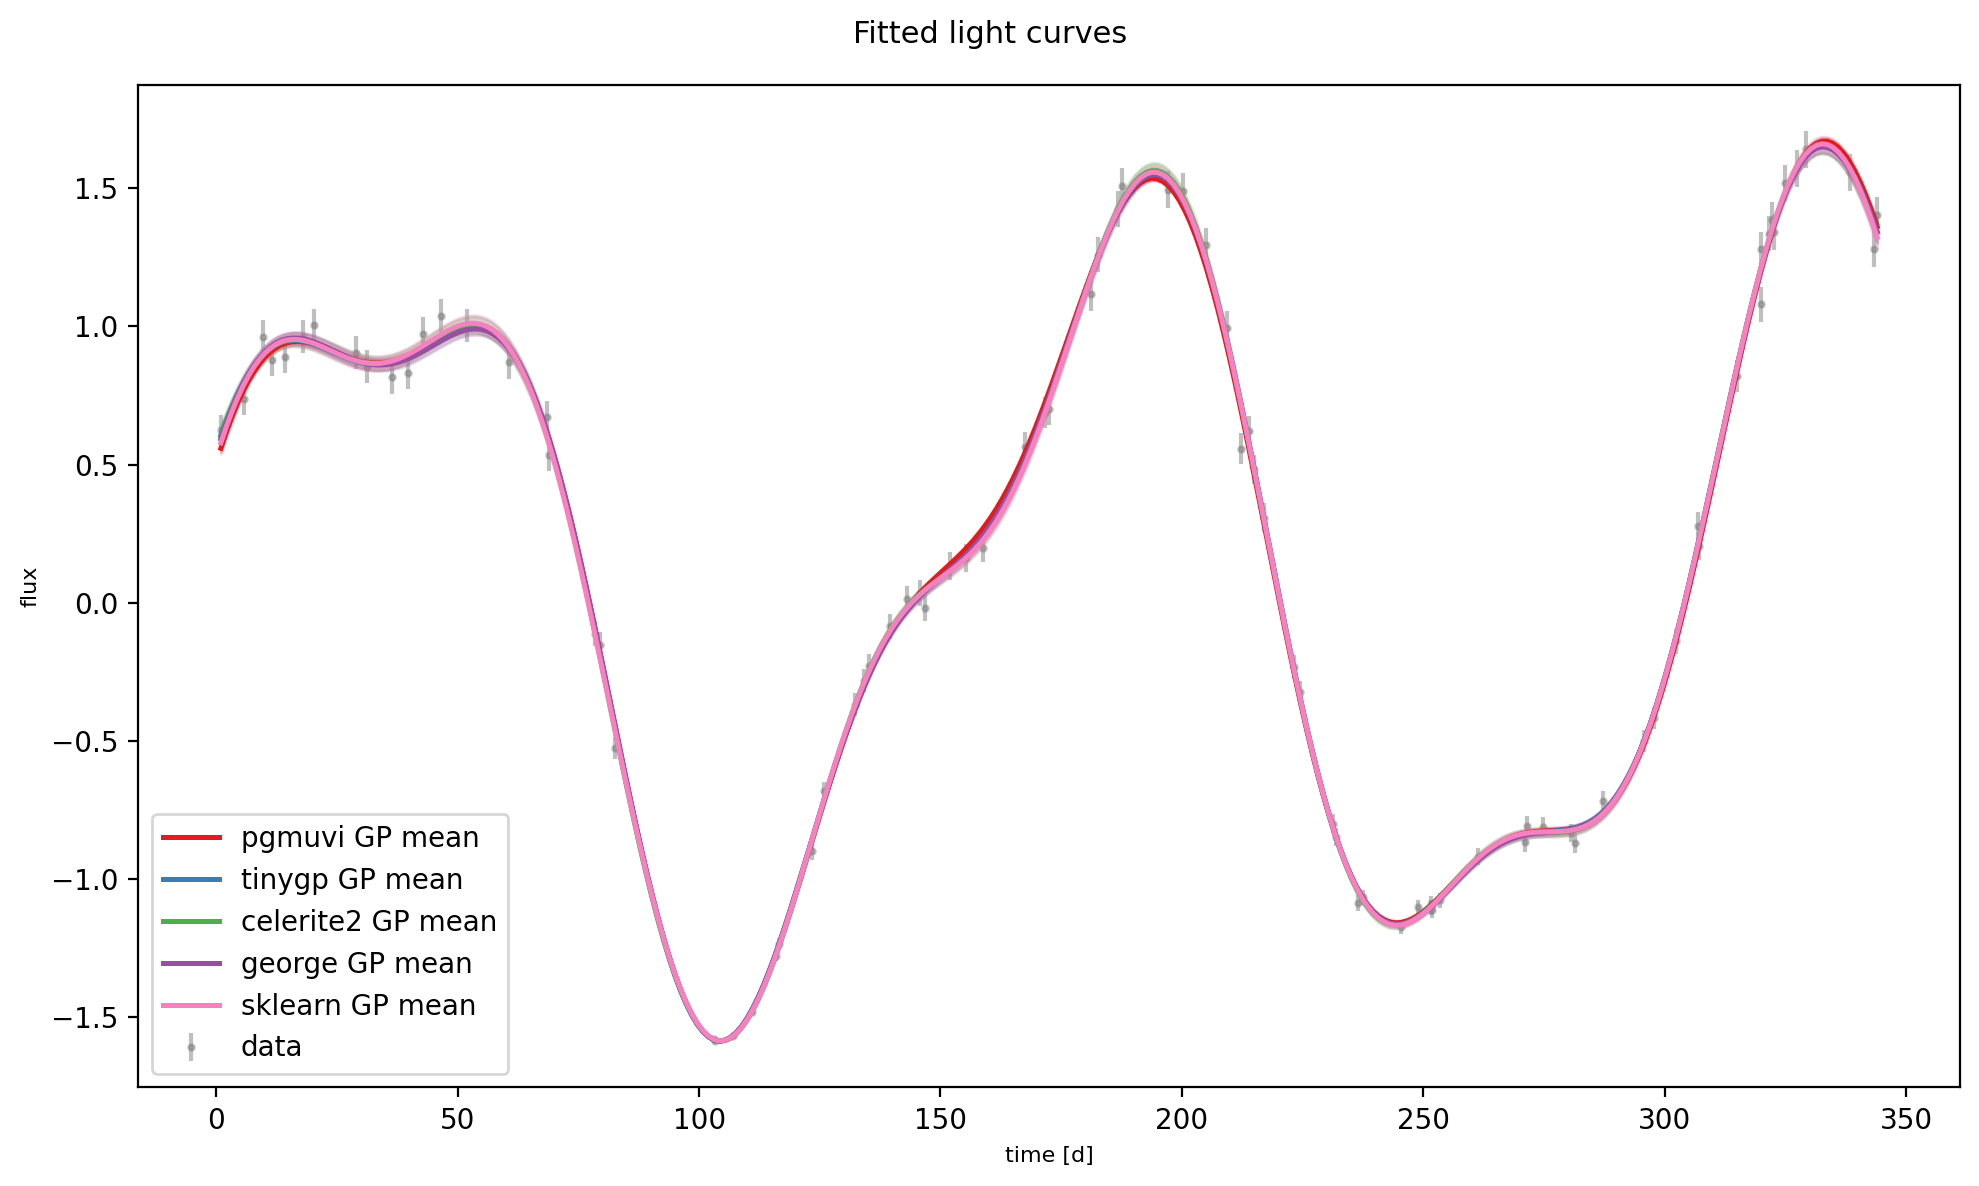

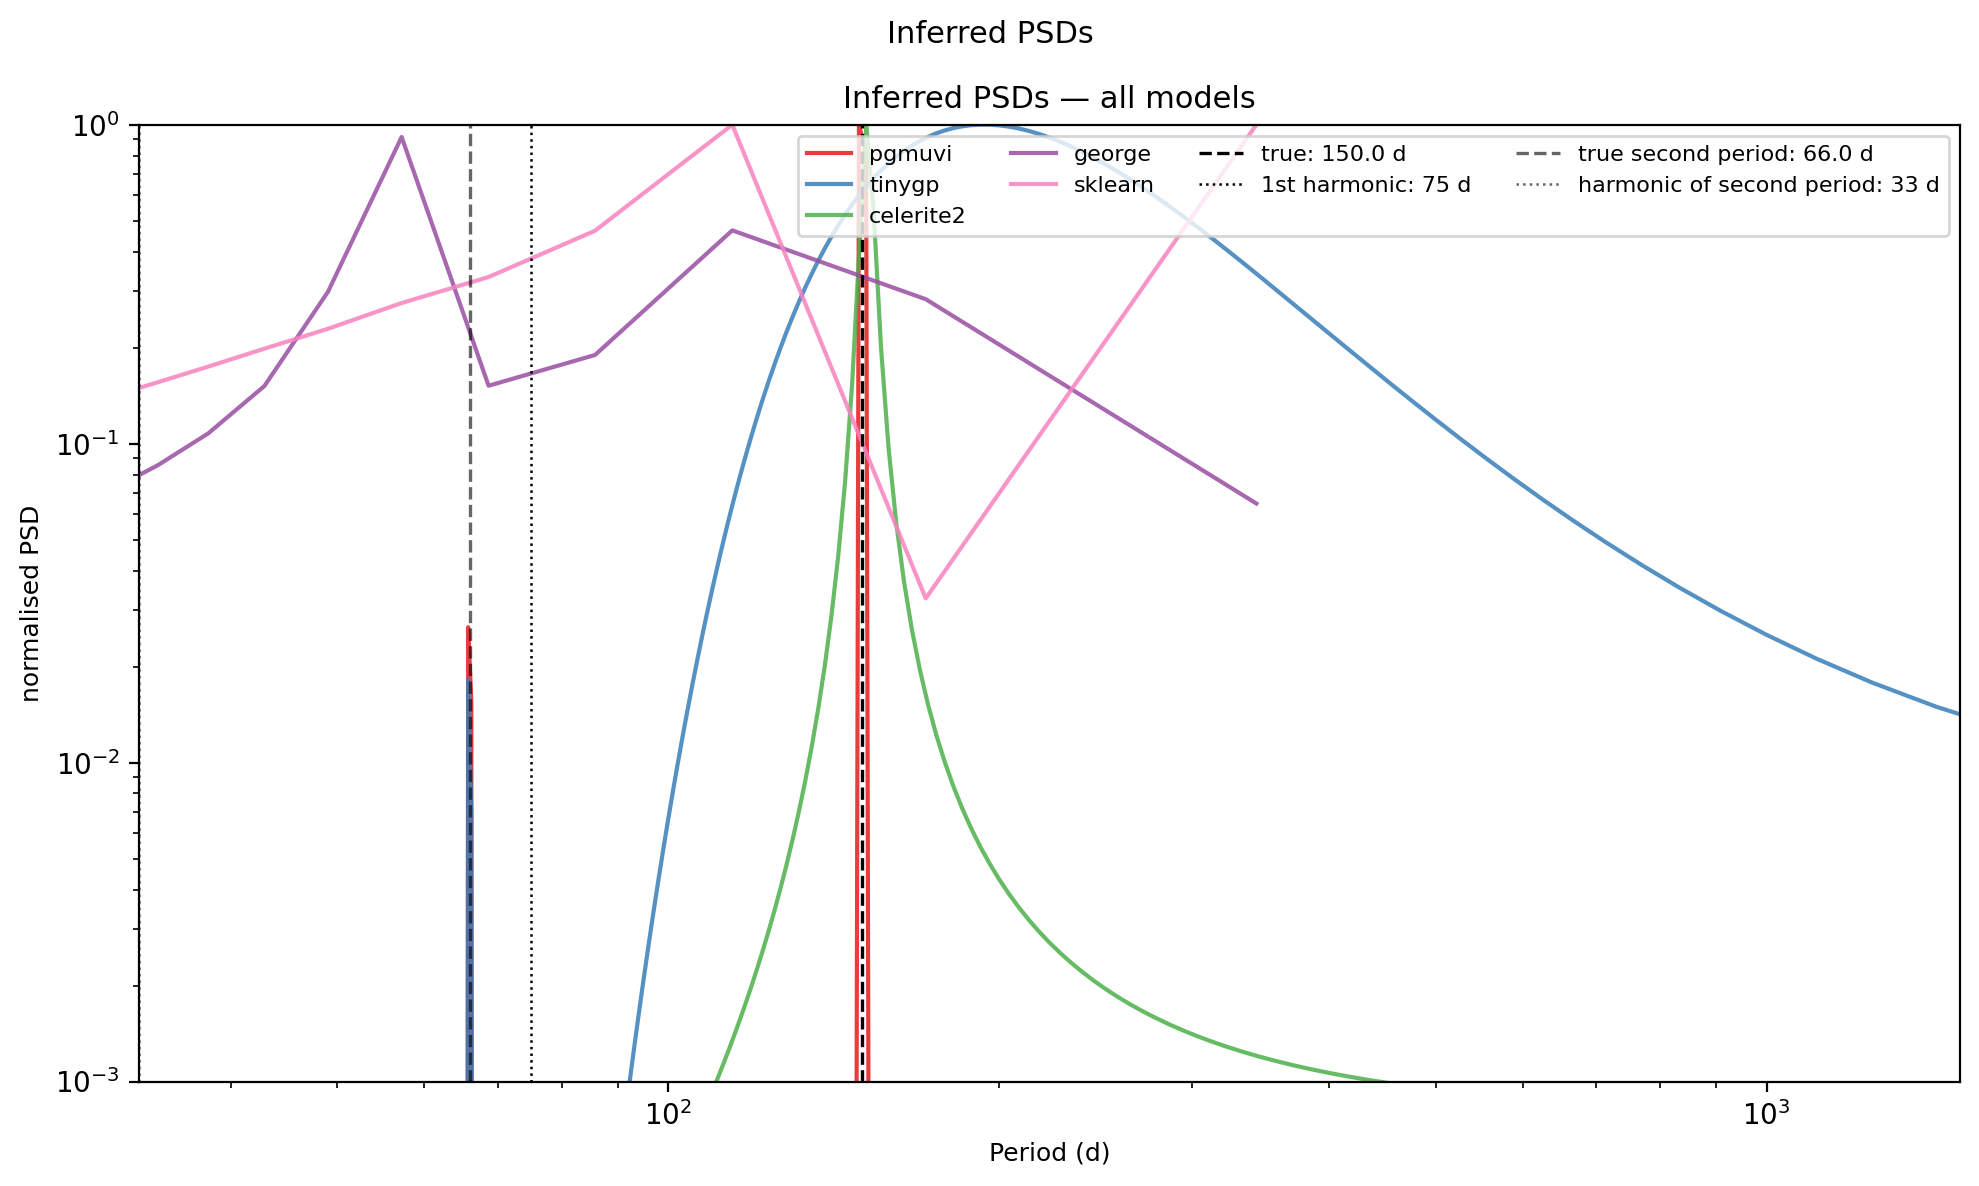

Saved comparison_1d.pdf


In [44]:
COLORS = {
    'pgmuvi':   '#e41a1c',
    'tinygp':   '#377eb8',
    'celerite2':'#4daf4a',
    'george':   '#984ea3',
    'GPy':      '#ff7f00',
    'gpflow':   '#a65628',
    'sklearn':  '#f781bf',
    'gpjax':    '#999999',
}

available_fits = list(preds_1d.keys())
n_avail = len(available_fits)

if n_avail == 0:
    print('No fitted models to plot.')
else:
    ncols = min(n_avail, 4)
    nrows_fits = (n_avail + ncols - 1) // ncols

    fig = plt.figure(figsize = (10, 6), dpi=200)
    ax = fig.add_subplot(111)
    # gs  = gridspec.GridSpec(
    #     nrows_fits + 1, ncols,
    #     height_ratios=[3] * nrows_fits + [3.5],
    #     hspace=0.5, wspace=0.35)
    ax.errorbar(x1, y1, yerr=ye1, fmt='.', color='grey',
                    alpha=0.5, markersize=4, label='data', zorder=1)

    for idx, name in enumerate(available_fits):
        row, col = divmod(idx, ncols)
        # ax = fig.add_subplot(gs[row, col])
        xg, mu, std = preds_1d[name]
        c = COLORS.get(name, 'steelblue')

        ax.plot(xg, mu, color=c, lw=1.8, label=f'{name} GP mean', zorder=3)
        if std is not None:
            ax.fill_between(xg, mu - std, mu + std,
                            alpha=0.25, color=c, zorder=2)
    # ax.set_title(name, fontsize=10, color=c, fontweight='bold')
    ax.legend()
    ax.set_xlabel('time [d]', fontsize=8)
    ax.set_ylabel('flux', fontsize=8)

    fig.suptitle('Fitted light curves', fontsize=11)
    fig.tight_layout()
    plt.savefig('Lightcurves_1d.png', bbox_inches='tight')


    # PSD panel spanning all columns
    fig_psd = plt.figure(figsize = (10,6), dpi=200)
    ax_psd = fig_psd.add_subplot(111)
    for name in psds_1d:
        print(name)
        fx, pwr = psds_1d[name]
        print(fx.min(), fx.max(), pwr.min(), pwr.max())
        print(fx.shape, pwr.shape)
        c = COLORS.get(name, 'steelblue')
        mask = (fx > 0) & (fx <= 0.12)
        freq_loc = fx[mask]
        try:
            pwr_loc = pwr[mask]
        except IndexError:
            pwr_loc = pwr[1][:-1][mask]
        ax_psd.plot(1/freq_loc, pwr_loc,
                    color=c, lw=1.5, label=name, alpha=0.85)
    # ax_psd.axvline(TRUE_FREQ, ls='--', color='k', lw=1.2,
                #    label=f'true: {TRUE_PERIOD} d')
    # ax_psd.axvline(2 * TRUE_FREQ, ls=':', color='k', lw=0.9,
                #    label=f'harmonic: {TRUE_PERIOD / 2:.0f} d')
    ax_psd.axvline(TRUE_PERIOD, ls='--', color='k', lw=1.2,
                   label=f'true: {TRUE_PERIOD} d')
    ax_psd.axvline(0.5 * TRUE_PERIOD, ls=':', color='k', lw=0.9,
                   label=f'1st harmonic: {TRUE_PERIOD / 2:.0f} d')
    if len(TRUE_PERIODS) > 1:
        ax_psd.axvline(TRUE_PERIODS[1], ls='--', color='k', lw=1.2,
                       label=f'true second period: {TRUE_PERIODS[1]} d',
                       alpha = 0.6)
        ax_psd.axvline(0.5 * TRUE_PERIODS[1], ls=':', color='k', lw=0.9,
                       label=f'harmonic of second period: {TRUE_PERIODS[1] / 2:.0f} d',
                       alpha=0.6)
    ax_psd.set_xlabel('Period (d)', fontsize=9)
    ax_psd.set_ylabel('normalised PSD', fontsize=9)
    ax_psd.set_title('Inferred PSDs — all models', fontsize=11)
    ax_psd.legend(ncol=4, fontsize=8, loc='upper right')
    # ax_psd.set_xlim(0, 0.12)
    # ax_psd.set_xlim(0.01, 0.12)
    # ax_psd.set_xlim(0.1, 1/0.12)
    ax_psd.set_xlim(min(TRUE_PERIODS)/2, max(TRUE_PERIODS)*10)
    ax_psd.loglog()
    ax_psd.set_ylim(0.001, 1.)
    # ax_psd.set_xaxis("log")
    fig_psd.suptitle('Inferred PSDs', fontsize=11)
    fig_psd.tight_layout()


    plt.savefig('PSDs_1d.png', bbox_inches='tight')
    plt.show()
    print('Saved comparison_1d.pdf')

## 2D (multiwavelength) comparison

Multiwavelength data has inputs $(t, \lambda)$, requiring a kernel defined
over 2D space. `pgmuvi` provides a built-in 2D SMK; `tinygp` requires a
custom kernel class; all other tools in this comparison are restricted to 1D inputs.

### `pgmuvi` — 2D spectral mixture GP

In [37]:
t0 = time.perf_counter()
res_pgmuvi_2d = lc_2d.fit(
    model='2D',
    num_mixtures=Q_MIXTURES,
    training_iter=1000,
    miniter=50,
    lr=0.05,
)
timings['pgmuvi_2d'] = time.perf_counter() - t0

print('pgmuvi 2D  | loss:', round(float(res_pgmuvi_2d['loss'][-1]), 3),
      ' | time:', round(timings['pgmuvi_2d'], 2), 's')

mm2 = lc_2d.model.covar_module.mixture_means.detach()
time_freqs_2d = mm2[:, 0, 0].detach().cpu().numpy()
print('  fitted time frequencies:', time_freqs_2d,
      '-> periods:', 1.0 / time_freqs_2d)

mean_module.constant: 0.028102993965148926
covar_module.mixture_weights: tensor([0.6931, 0.6931])
covar_module.mixture_means: tensor([[[9.4067, 9.4067]],

        [[9.4067, 9.4067]]])
covar_module.mixture_scales: tensor([[[0.6931, 0.6931]],

        [[0.6931, 0.6931]]])


 35%|███▍      | 348/1000 [00:14<00:26, 24.78it/s]

Average change in loss over the last 30 iterations
                    was 9.44400166417925e-06.
 This is < 1e-05, so we will end training here.
pgmuvi 2D  | loss: 0.904  | time: 15.84 s
  fitted time frequencies: [13.842627 13.842627] -> periods: [0.07224063 0.07224063]


### `tinygp` — custom 2D spectral mixture kernel

The 2D SMK is a **product over dimensions** of per-dimension spectral sums:

$$k_\mathrm{SM}^{(2D)}(\mathbf{x},\mathbf{x}') =
\prod_{d=1}^{2}\sum_{q=1}^{Q} w_q
\exp\!\bigl(-2\pi^2 v_q^{(d)2}\tau_d^2\bigr)\cos(2\pi\mu_q^{(d)}\tau_d).$$

In [38]:
class SMK2D(TinyKernel if HAVE_TINYGP else object):
    r'''2-D Spectral Mixture Kernel (product over dimensions, sum over mixtures).

    Parameters
    ----------
    log_weights : jnp.ndarray, shape (Q,)
        Log of the mixture weights w_q.
    log_freqs : jnp.ndarray, shape (Q, 2)
        Log of the mixture-mean frequencies mu_q for each dimension.
    log_scales : jnp.ndarray, shape (Q, 2)
        Log of the bandwidth parameters v_q for each dimension.
    '''
    log_weights : 'jnp.ndarray'   # (Q,)
    log_freqs   : 'jnp.ndarray'   # (Q, 2)
    log_scales  : 'jnp.ndarray'   # (Q, 2)

    def evaluate(self, X1, X2):
        w   = jnp.exp(self.log_weights)
        mu  = jnp.exp(self.log_freqs)
        v   = jnp.exp(self.log_scales)
        tau = X1 - X2  # (2,)

        cos_term = jnp.cos(2 * jnp.pi * mu * tau)
        exp_term = jnp.exp(-2 * jnp.pi**2 * (v**2) * (tau**2))

        return jnp.sum(w * jnp.prod(cos_term * exp_term, axis=1))


if HAVE_TINYGP:
    x2_j  = jnp.asarray(lc_2d.xdata.detach().cpu().numpy())
    y2_j  = jnp.asarray(lc_2d.ydata.detach().cpu().numpy())
    ye2_j = jnp.asarray(lc_2d.yerr.detach().cpu().numpy())
    mean2d = float(np.mean(np.asarray(y2_j)))

    wl_range = max(WAVELENGTHS) - min(WAVELENGTHS)
    wl_freq  = 1.0 / wl_range
    init_freqs_2d = jnp.array(
        [[TRUE_FREQ,     wl_freq],
         [2 * TRUE_FREQ, 2 * wl_freq]]
    )
    kernel_tiny_2d = SMK2D(
        log_weights=jnp.log(jnp.ones(Q_MIXTURES) * 0.5),
        log_freqs  =jnp.log(init_freqs_2d),
        log_scales =jnp.log(jnp.ones((Q_MIXTURES, 2)) * 0.002),
    )

    @jax.jit
    @jax.value_and_grad
    def _neg_ll_tiny2d(params):
        gp = TinyGP(params, x2_j, diag=ye2_j**2, mean=mean2d)
        return -gp.log_probability(y2_j)

    opt2d   = optax.adam(0.05)
    state2d = opt2d.init(eqx.filter(kernel_tiny_2d, eqx.is_inexact_array))

    t0 = time.perf_counter()
    for _ in range(1000):
        loss2d, grads2d = _neg_ll_tiny2d(kernel_tiny_2d)
        upd2d, state2d  = opt2d.update(
            grads2d, state2d,
            eqx.filter(kernel_tiny_2d, eqx.is_inexact_array))
        kernel_tiny_2d = eqx.apply_updates(kernel_tiny_2d, upd2d)
    timings['tinygp_2d'] = time.perf_counter() - t0

    tf_fit_2d = np.exp(np.asarray(kernel_tiny_2d.log_freqs))[:, 0]
    print('tinygp 2D  | loss:', round(float(loss2d), 3),
          ' | time:', round(timings['tinygp_2d'], 2), 's')
    print('  fitted time periods:', 1.0 / tf_fit_2d)
else:
    print('tinygp not installed.')

tinygp 2D  | loss: -276.357  | time: 37.98 s
  fitted time periods: [103.4588  376.66473]


### `celerite2` — 2D limitation

`celerite2` is designed exclusively for 1D semiseparable covariance matrices
and cannot accept two-dimensional `(time, wavelength)` input:

In [39]:
if HAVE_CELERITE:
    x2_c  = lc_2d.xdata.detach().cpu().numpy()   # shape (N, 2)
    y2_c  = lc_2d.ydata.detach().cpu().numpy()
    ye2_c = lc_2d.yerr.detach().cpu().numpy()

    kernel_c2d = c2terms.SHOTerm(
        sigma=0.7, rho=TRUE_PERIOD, tau=2 * TRUE_PERIOD)
    gp_c2d = celerite2.GaussianProcess(
        kernel_c2d, mean=float(np.mean(y2_c)))
    try:
        gp_c2d.compute(x2_c, yerr=ye2_c)
        print('Unexpected: celerite2 accepted 2D input.')
    except (TypeError, ValueError) as exc:
        print('celerite2 rejects 2D input (expected):')
        print(f'  {type(exc).__name__}: {str(exc)[:200]}')
else:
    print('celerite2 not installed.')

celerite2 rejects 2D input (expected):
  ValueError: The input coordinates must be one dimensional


## Summary comparison

In [42]:
_NA = 'N/A'

HEADERS = [
    'Package', 'Kernel (1D)', 'Spectral shape',
    'Optimizer', 'GPU', '2D input',
    'Code lines', 'Time for 1D lightcurve (s)',
]

_t = timings   # shorthand

ROWS = [
    ['pgmuvi',   'SpectralMixture (built-in)', 'Gaussian',
     'Adam (PyTorch)', 'Yes (CUDA)', 'Yes (native)',
     f"{code_lines.get('pgmuvi', '~1')}",
     f"{_t.get('pgmuvi', float('nan')):.2f}"],
    ['tinygp',   'Custom SMK1D (user class)', 'Gaussian',
     'optax Adam (JAX)', 'XLA JIT', '2D class (user)',
     f"{code_lines.get('tinygp', '~15')}",
     f"{_t.get('tinygp', float('nan')):.2f}"],
    ['celerite2','SHOTerm (Lorentzian approx)', 'Lorentzian',
     'scipy L-BFGS-B', 'No (O(N) CPU)', 'No',
     f"{code_lines.get('celerite2', '~4')}",
     f"{_t.get('celerite2', float('nan')):.3f}"],
    ['george',   'ExpSquared x Cosine', 'Gaussian',
     'scipy L-BFGS-B', 'No', 'No',
     f"{code_lines.get('george', '~4')}",
     f"{_t.get('george', float('nan')):.3f}"],
    ['GPy',      'ExpQuadCosine (built-in)', 'Gaussian',
     'scipy L-BFGS-B', 'No', 'Manual',
     f"{code_lines.get('GPy', '~3')}",
     f"{_t.get('GPy', float('nan')):.3f}"],
    ['gpflow',   'SquaredExp x Cosine', 'Gaussian',
     'TF Scipy', 'Yes (TF/GPU)', 'Manual',
     f"{code_lines.get('gpflow', '~4')}",
     f"{_t.get('gpflow', float('nan')):.2f}"],
    ['sklearn',  'RBF x ExpSineSquared', 'Non-Gaussian',
     'scipy L-BFGS-B', 'No', 'Partial',
     f"{code_lines.get('sklearn', '~3')}",
     f"{_t.get('sklearn', float('nan')):.3f}"],
    ['gpjax',    'Custom SMK (user class)', 'Gaussian',
     'optax Adam (JAX)', 'XLA JIT', 'Custom kernel',
     f"{code_lines.get('gpjax', '~20')}",
     f"{_t.get('gpjax', float('nan')):.2f}"],
]

col_w = [
    max(len(h), max(len(str(r[i])) for r in ROWS))
    for i, h in enumerate(HEADERS)
]

def _fmt_row(cells, widths):
    return '|' + '|'.join(f' {str(c):<{w}} ' for c, w in zip(cells, widths)) + '|'

sep = '+' + '+'.join('-' * (w + 2) for w in col_w) + '+'
print(sep)
print(_fmt_row(HEADERS, col_w))
print(sep)
for row in ROWS:
    print(_fmt_row(row, col_w))
print(sep)
print()
print('Notes:')
print('  nan = package was not available in this run.')
print('  sklearn ExpSineSquared uses sin^2, not cos — not the exact SMK.')
print('  GPy/gpflow 2D: requires user-constructed product/sum kernels.')

+-----------+-----------------------------+----------------+------------------+---------------+-----------------+------------+----------------------------+
| Package   | Kernel (1D)                 | Spectral shape | Optimizer        | GPU           | 2D input        | Code lines | Time for 1D lightcurve (s) |
+-----------+-----------------------------+----------------+------------------+---------------+-----------------+------------+----------------------------+
| pgmuvi    | SpectralMixture (built-in)  | Gaussian       | Adam (PyTorch)   | Yes (CUDA)    | Yes (native)    | 1          | 11.19                      |
| tinygp    | Custom SMK1D (user class)   | Gaussian       | optax Adam (JAX) | XLA JIT       | 2D class (user) | 16         | 19.00                      |
| celerite2 | SHOTerm (Lorentzian approx) | Lorentzian     | scipy L-BFGS-B   | No (O(N) CPU) | No              | 4          | 0.737                      |
| george    | ExpSquared x Cosine         | Gaussian       | sci

## Practical guidance

| | `pgmuvi` | `tinygp` | `celerite2` | `george` | `GPy` | `gpflow` | `sklearn` | `gpjax` |
|---|---|---|---|---|---|---|---|---|
| **1D SMK** | built-in | custom class | SHO proxy | ExpSq×Cos | ExpQuadCosine | SE×Cos | RBF×ExpSine† | custom class |
| **2D input** | native | custom class | ✗ | ✗ | manual | manual | partial | custom |
| **GPU support** | PyTorch | JAX/XLA | CPU only | CPU only | CPU only | TF/GPU | CPU only | JAX/XLA |
| **Backend** | PyTorch | JAX | numpy/C | numpy/C | numpy/C | TensorFlow | numpy/C | JAX |
| **Code lines (1D)** | ~1 | ~15 | ~4 | ~4 | ~3 | ~4 | ~3 | ~20 |

†sklearn's `ExpSineSquared` uses $\sin^2$ not $\cos$ — not the exact SMK.

### When to choose each tool

- **`pgmuvi`** is the natural choice for astronomical multiwavelength light curves.
  Built-in 1D/2D SMK, MLS initialisation, and PyTorch Adam are pre-configured
  behind a single `.fit()` call. GPU-accelerated via PyTorch.
- **`celerite2`** should be preferred when $O(N)$ speed on a **single 1D time series**
  is the priority and the Lorentzian spectral shape is acceptable.
- **`george`** is a lightweight, battle-tested 1D GP library with analytic gradients
  and scipy-based optimisation; CPU-only and 1D-only.
- **`GPy`** has a broad kernel catalogue (including `ExpQuadCosine` ≡ SMK component)
  and a convenient model API, but is CPU-only and no longer actively developed.
- **`gpflow`** offers GPU acceleration via TensorFlow and a clean API; the SMK
  must be composed from built-in kernels.
- **`scikit-learn`** is the easiest entry point for general ML, but its kernel set
  does not include a true SMK and it scales poorly to large datasets.
- **`tinygp`** and **`gpjax`** are ideal when you need **total kernel flexibility**
  and JAX auto-diff/JIT. Both can implement any kernel that `pgmuvi` uses,
  but require substantially more user code.